In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    04_eda_campaign.ipynb                                   ║
# ║  EDA comparing spectral and spatial characteristics across campaigns       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from prettytable import PrettyTable
from pathlib import Path
from scipy.stats import f_oneway, kruskal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from brainvision.constants import *
from brainvision.data.io import load_processed_patients
from brainvision.device import get_device, print_device_info

RESULTS_DIR = Path(RESULTS_DIR)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Campaign EDA notebook ready")

Campaign EDA notebook ready


In [2]:
# ── Load all campaigns ────────────────────────────────────────────────
def load_all_campaigns() -> dict:
    print("Loading campaigns...")
    campaigns = {c: load_processed_patients(PROCESSED_DIRS[c])
                 for c in [1, 2, 3]}
    for c, patients in campaigns.items():
        total_images = len(patients)
        n_patients   = len(set(p['id'].split('-')[0] for p in patients))
        print(f"  Campaign {c}: {total_images} images, {n_patients} patients")
    return campaigns

campaigns = load_all_campaigns()

CAMPAIGN_LABELS = {
    1: "Campaign 1\n(Mar 2015 – Jun 2016)",
    2: "Campaign 2\n(Oct 2016 – Apr 2017)",
    3: "Campaign 3\n(Jul 2019 – Oct 2019)",
}
CAMPAIGN_COLORS = {1: '#378ADD', 2: '#D85A30', 3: '#5DCAA5'}
CLASS_COLORS    = {
    0: '#5DCAA5',   # NT
    1: '#D85A30',   # TT
    2: '#378ADD',   # BV
    3: '#888780',   # BG
}

Loading campaigns...
  Loaded  27 patients from ../processed/first_campaign
  Loaded  24 patients from ../processed/second_campaign
  Loaded  10 patients from ../processed/third_campaign
  Campaign 1: 27 images, 16 patients
  Campaign 2: 24 images, 10 patients
  Campaign 3: 10 images, 8 patients


In [3]:
# ── Per-campaign class distribution ───────────────────────────────────
def compute_campaign_class_stats(campaigns: dict) -> dict:
    """Compute pixel counts and percentages per class per campaign."""
    stats = {}

    for c_id, patients in campaigns.items():
        counts     = {i: 0 for i in range(N_CLASSES)}
        n_labelled = 0
        n_images_with_tt = 0
        image_tt_counts  = []

        for p in patients:
            label_map = p['labels']
            has_tt    = False

            for i in range(N_CLASSES):
                cnt = (label_map == (i + 1)).sum()
                counts[i] += cnt

            tt_cnt = (label_map == 2).sum()
            if tt_cnt > 0:
                has_tt = True
                n_images_with_tt += 1
            image_tt_counts.append(tt_cnt)

        total  = sum(counts.values())
        stats[c_id] = {
            'counts'         : counts,
            'total'          : total,
            'pcts'           : {i: counts[i]/total*100 if total > 0 else 0
                                for i in range(N_CLASSES)},
            'nt_tt_ratio'    : counts[0]/counts[1] if counts[1] > 0 else float('inf'),
            'n_images'       : len(patients),
            'n_patients'     : len(set(p['id'].split('-')[0] for p in patients)),
            'n_images_with_tt': n_images_with_tt,
            'tt_pct_images'  : n_images_with_tt / len(patients) * 100,
            'image_tt_counts': image_tt_counts,
        }

    return stats


campaign_stats = compute_campaign_class_stats(campaigns)

# Print summary table
table = PrettyTable()
table.field_names = [
    "Campaign", "Images", "Patients", "Images w/ TT",
    "NT%", "TT%", "BV%", "BG%", "NT:TT ratio"
]
for col in table.field_names[1:]:
    table.align[col] = 'r'

for c_id, s in campaign_stats.items():
    table.add_row([
        f"Campaign {c_id}",
        s['n_images'],
        s['n_patients'],
        f"{s['n_images_with_tt']} ({s['tt_pct_images']:.0f}%)",
        f"{s['pcts'][0]:.1f}%",
        f"{s['pcts'][1]:.1f}%",
        f"{s['pcts'][2]:.1f}%",
        f"{s['pcts'][3]:.1f}%",
        f"{s['nt_tt_ratio']:.1f}",
    ])

print(f"\n{'═'*90}")
print("  CAMPAIGN CLASS DISTRIBUTION")
print(f"{'═'*90}")
print(table)


══════════════════════════════════════════════════════════════════════════════════════════
  CAMPAIGN CLASS DISTRIBUTION
══════════════════════════════════════════════════════════════════════════════════════════
+------------+--------+----------+--------------+-------+------+-------+-------+-------------+
|  Campaign  | Images | Patients | Images w/ TT |   NT% |  TT% |   BV% |   BG% | NT:TT ratio |
+------------+--------+----------+--------------+-------+------+-------+-------+-------------+
| Campaign 1 |     27 |       16 |      9 (33%) | 37.6% | 4.2% | 14.5% | 43.7% |         8.9 |
| Campaign 2 |     24 |       10 |     17 (71%) | 48.7% | 3.0% | 15.2% | 33.1% |        16.3 |
| Campaign 3 |     10 |        8 |      7 (70%) |  8.2% | 5.8% |  6.0% | 80.0% |         1.4 |
+------------+--------+----------+--------------+-------+------+-------+-------+-------------+


In [4]:
# ── Collect per-class spectra per campaign ────────────────────────────
def collect_spectra_per_campaign(campaigns: dict,
                                  max_pixels_per_class: int = 5000
                                  ) -> dict:
    """
    Collect pixel spectra grouped by campaign and class.
    Subsamples to max_pixels_per_class for memory efficiency.
    """
    spectra = {c: {i: [] for i in range(N_CLASSES)} for c in campaigns}

    for c_id, patients in campaigns.items():
        print(f"  Collecting Campaign {c_id} spectra...")
        rng = np.random.default_rng(seed=42)

        for p in patients:
            cube      = p['processed']   # (H, W, 128)
            label_map = p['labels']      # (H, W)
            flat_cube = cube.reshape(-1, cube.shape[2])
            flat_labels = label_map.reshape(-1)

            for i in range(N_CLASSES):
                mask = flat_labels == (i + 1)
                if mask.sum() == 0:
                    continue
                px   = flat_cube[mask]
                # Subsample if too many
                if len(px) > max_pixels_per_class // len(patients):
                    n   = max(1, max_pixels_per_class // len(patients))
                    idx = rng.choice(len(px), n, replace=False)
                    px  = px[idx]
                spectra[c_id][i].append(px)

        for i in range(N_CLASSES):
            if spectra[c_id][i]:
                spectra[c_id][i] = np.vstack(spectra[c_id][i])
            else:
                spectra[c_id][i] = np.zeros((0, N_DECIMATED_BANDS))

        for i in range(N_CLASSES):
            print(f"    {CLASS_NAMES[i+1]:<25}: "
                  f"{len(spectra[c_id][i]):,} pixels")

    return spectra


print("Collecting spectra...")
campaign_spectra = collect_spectra_per_campaign(campaigns)

    Normal Tissue (NT)       : 4,625 pixels
    Tumour Tissue (TT)       : 1,376 pixels
    Blood Vessel (BV)        : 4,331 pixels
    Background (BG)          : 4,440 pixels
    Normal Tissue (NT)       : 4,160 pixels
    Tumour Tissue (TT)       : 3,284 pixels
    Blood Vessel (BV)        : 3,952 pixels
    Background (BG)          : 4,576 pixels
    Normal Tissue (NT)       : 4,361 pixels
    Tumour Tissue (TT)       : 3,372 pixels
    Blood Vessel (BV)        : 4,424 pixels
    Background (BG)          : 5,000 pixels


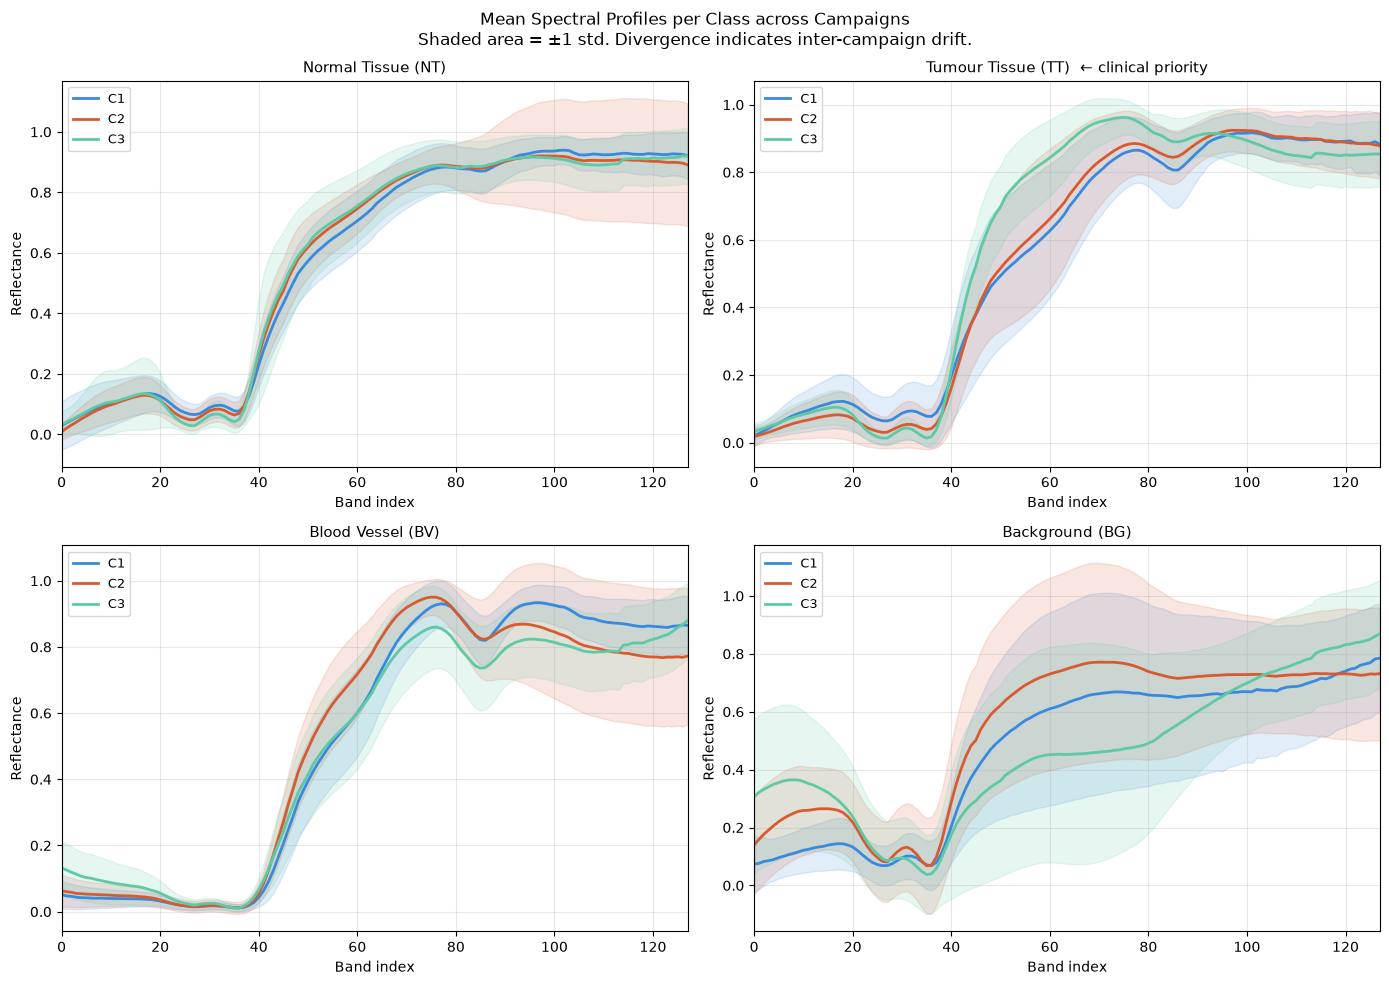

Saved → ../results/campaign_mean_spectra.png


In [5]:
# ── Mean spectral profiles per campaign ───────────────────────────────
def plot_mean_spectra_per_campaign(campaign_spectra: dict):
    """
    Plot mean spectral profile of each class across all three campaigns.
    Shows inter-campaign spectral drift.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Mean Spectral Profiles per Class across Campaigns\n"
        "Shaded area = ±1 std. Divergence indicates inter-campaign drift.",
        fontsize=12
    )
    axes = axes.flatten()
    bands = np.arange(N_DECIMATED_BANDS)

    for i in range(N_CLASSES):
        ax = axes[i]
        ax.set_title(f"{CLASS_NAMES[i+1]}", fontsize=11)

        for c_id in [1, 2, 3]:
            px = campaign_spectra[c_id][i]
            if len(px) == 0:
                continue
            mean = px.mean(axis=0)
            std  = px.std(axis=0)
            ax.plot(bands, mean,
                    color     = CAMPAIGN_COLORS[c_id],
                    linewidth = 2,
                    label     = f"C{c_id}")
            ax.fill_between(bands, mean - std, mean + std,
                            alpha=0.15, color=CAMPAIGN_COLORS[c_id])

        ax.set_xlabel("Band index")
        ax.set_ylabel("Reflectance")
        ax.legend(fontsize=9)
        ax.set_xlim(0, N_DECIMATED_BANDS - 1)
        ax.grid(alpha=0.3)

        # Mark TT for clinical priority
        if i == 1:
            ax.set_title(f"{CLASS_NAMES[2]}  ← clinical priority", fontsize=11)

    plt.tight_layout()
    out = RESULTS_DIR / "campaign_mean_spectra.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")


plot_mean_spectra_per_campaign(campaign_spectra)

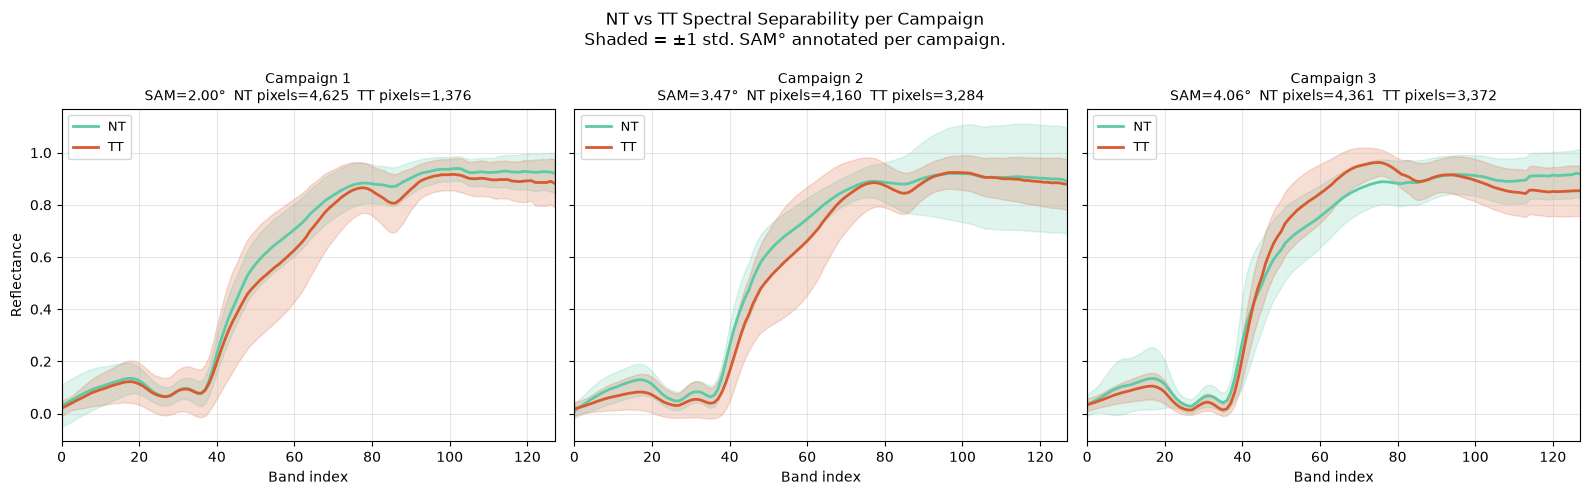

Saved → ../results/campaign_nt_tt_separability.png


In [6]:
# ── NT vs TT spectra per campaign — separability ─────────────────────
def plot_nt_tt_separability_per_campaign(campaign_spectra: dict):
    """
    Compare NT and TT mean spectra within each campaign.
    Reveals whether NT/TT separability differs across campaigns.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    fig.suptitle(
        "NT vs TT Spectral Separability per Campaign\n"
        "Shaded = ±1 std. SAM° annotated per campaign.",
        fontsize=12
    )
    bands = np.arange(N_DECIMATED_BANDS)

    for idx, c_id in enumerate([1, 2, 3]):
        ax     = axes[idx]
        nt_px  = campaign_spectra[c_id][0]
        tt_px  = campaign_spectra[c_id][1]

        if len(nt_px) == 0 or len(tt_px) == 0:
            ax.text(0.5, 0.5, f'No TT pixels\nin Campaign {c_id}',
                    ha='center', va='center', transform=ax.transAxes)
            continue

        nt_mean = nt_px.mean(axis=0)
        tt_mean = tt_px.mean(axis=0)
        nt_std  = nt_px.std(axis=0)
        tt_std  = tt_px.std(axis=0)

        # SAM
        sam_rad = np.arccos(np.clip(
            np.dot(nt_mean, tt_mean) /
            (np.linalg.norm(nt_mean) * np.linalg.norm(tt_mean) + 1e-8),
            -1, 1
        ))
        sam_deg = np.degrees(sam_rad)

        ax.plot(bands, nt_mean, color='#5DCAA5', linewidth=2, label='NT')
        ax.fill_between(bands, nt_mean - nt_std, nt_mean + nt_std,
                        alpha=0.2, color='#5DCAA5')

        ax.plot(bands, tt_mean, color='#D85A30', linewidth=2, label='TT')
        ax.fill_between(bands, tt_mean - tt_std, tt_mean + tt_std,
                        alpha=0.2, color='#D85A30')

        ax.set_title(
            f"Campaign {c_id}\nSAM={sam_deg:.2f}°  "
            f"NT pixels={len(nt_px):,}  TT pixels={len(tt_px):,}",
            fontsize=10
        )
        ax.set_xlabel("Band index")
        if idx == 0:
            ax.set_ylabel("Reflectance")
        ax.legend(fontsize=9)
        ax.set_xlim(0, N_DECIMATED_BANDS - 1)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    out = RESULTS_DIR / "campaign_nt_tt_separability.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")


plot_nt_tt_separability_per_campaign(campaign_spectra)

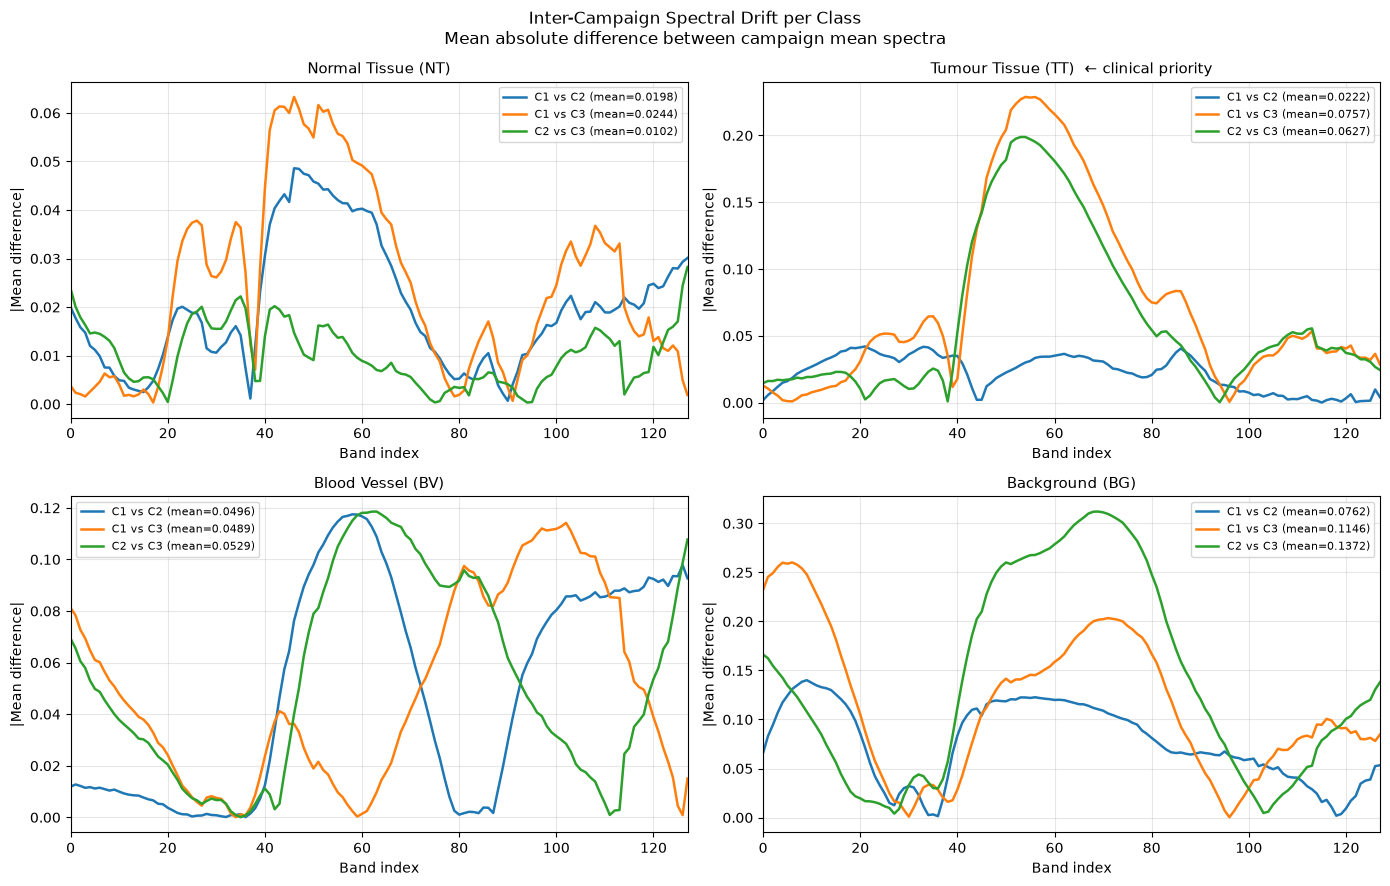

Saved → ../results/campaign_spectral_drift.png

════════════════════════════════════════════════════════════
  MEAN SPECTRAL DRIFT PER CLASS
════════════════════════════════════════════════════════════
+-------+----------+----------+----------+
| Class | C1 vs C2 | C1 vs C3 | C2 vs C3 |
+-------+----------+----------+----------+
|   NT  |  0.0198  |  0.0244  |  0.0102  |
|   TT  |  0.0222  |  0.0757  |  0.0627  |
|   BV  |  0.0496  |  0.0489  |  0.0529  |
|   BG  |  0.0762  |  0.1146  |  0.1372  |
+-------+----------+----------+----------+


In [7]:
# ── Inter-campaign spectral drift ─────────────────────────────────────
def plot_spectral_drift(campaign_spectra: dict):
    """
    Quantify inter-campaign spectral drift per class.
    Shows the mean absolute difference between campaign mean spectra.
    """
    bands    = np.arange(N_DECIMATED_BANDS)
    pairs    = [(1, 2), (1, 3), (2, 3)]
    pair_labels = ["C1 vs C2", "C1 vs C3", "C2 vs C3"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(
        "Inter-Campaign Spectral Drift per Class\n"
        "Mean absolute difference between campaign mean spectra",
        fontsize=12
    )
    axes = axes.flatten()

    drift_table = PrettyTable()
    drift_table.field_names = ["Class", "C1 vs C2", "C1 vs C3", "C2 vs C3"]

    for i in range(N_CLASSES):
        ax    = axes[i]
        drifts = {}

        for (ca, cb), lbl in zip(pairs, pair_labels):
            px_a = campaign_spectra[ca][i]
            px_b = campaign_spectra[cb][i]

            if len(px_a) == 0 or len(px_b) == 0:
                continue

            mean_a = px_a.mean(axis=0)
            mean_b = px_b.mean(axis=0)
            diff   = np.abs(mean_a - mean_b)
            drifts[lbl] = diff

            ax.plot(bands, diff, linewidth=1.8, label=f"{lbl} (mean={diff.mean():.4f})")

        drift_table.add_row([
            CLASS_NAMES_SHORT[i+1],
            f"{drifts.get('C1 vs C2', np.array([0])).mean():.4f}",
            f"{drifts.get('C1 vs C3', np.array([0])).mean():.4f}",
            f"{drifts.get('C2 vs C3', np.array([0])).mean():.4f}",
        ])

        ax.set_title(f"{CLASS_NAMES[i+1]}", fontsize=11)
        ax.set_xlabel("Band index")
        ax.set_ylabel("|Mean difference|")
        ax.legend(fontsize=8)
        ax.set_xlim(0, N_DECIMATED_BANDS - 1)
        ax.grid(alpha=0.3)
        if i == 1:
            ax.set_title(f"{CLASS_NAMES[2]}  ← clinical priority", fontsize=11)

    plt.tight_layout()
    out = RESULTS_DIR / "campaign_spectral_drift.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")

    print(f"\n{'═'*60}")
    print("  MEAN SPECTRAL DRIFT PER CLASS")
    print(f"{'═'*60}")
    print(drift_table)


plot_spectral_drift(campaign_spectra)

PCA — Tumour Tissue (TT):


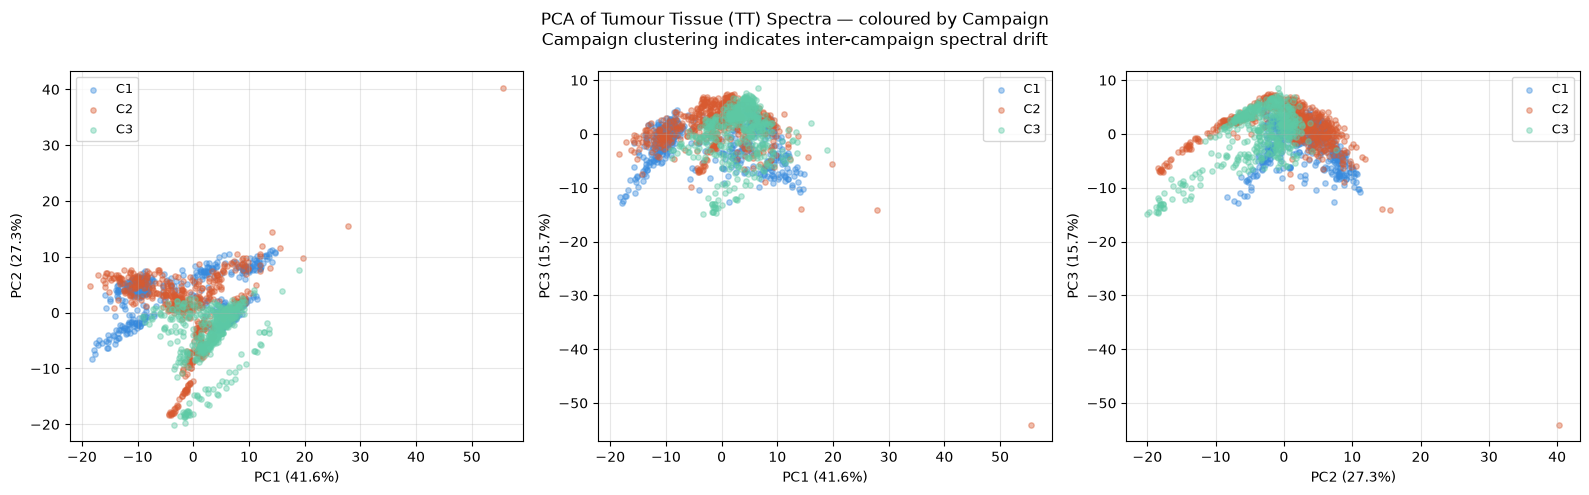

Saved → ../results/campaign_pca_tumour.png

PCA variance explained: PC1=41.6%  PC2=27.3%  PC3=15.7%  Total=84.6%

PCA — Normal Tissue (NT):


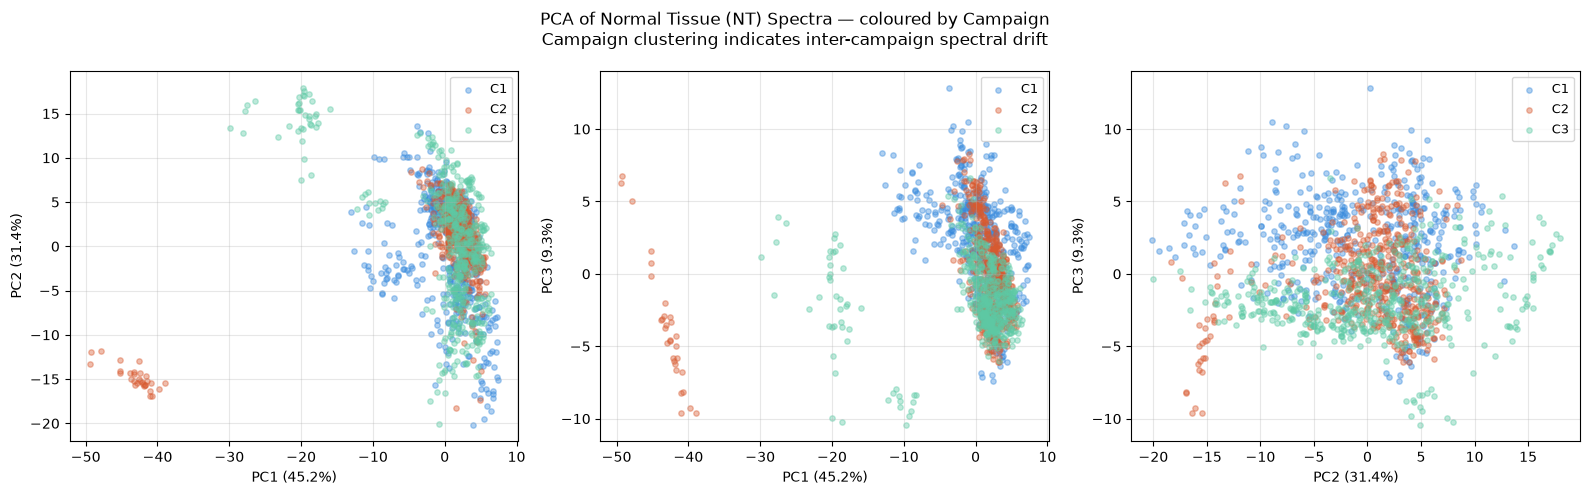

Saved → ../results/campaign_pca_normal.png

PCA variance explained: PC1=45.2%  PC2=31.4%  PC3=9.3%  Total=85.9%


In [8]:
# ── PCA visualisation — campaign clustering ───────────────────────────
def plot_pca_campaign_clustering(campaign_spectra: dict,
                                  class_idx: int = 1,
                                  n_samples: int = 500):
    """
    PCA of TT (or any class) spectra coloured by campaign.
    Shows whether campaigns cluster separately in spectral space.
    """
    cls_name = CLASS_NAMES[class_idx + 1]
    all_px   = []
    labels   = []

    rng = np.random.default_rng(42)
    for c_id in [1, 2, 3]:
        px = campaign_spectra[c_id][class_idx]
        if len(px) == 0:
            continue
        idx = rng.choice(len(px), min(n_samples, len(px)), replace=False)
        all_px.append(px[idx])
        labels.extend([c_id] * len(idx))

    if not all_px:
        print(f"No pixels found for class {cls_name}")
        return

    X      = np.vstack(all_px)
    labels = np.array(labels)

    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)

    pca    = PCA(n_components=3)
    X_pca  = pca.fit_transform(X_sc)

    var_explained = pca.explained_variance_ratio_ * 100

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f"PCA of {cls_name} Spectra — coloured by Campaign\n"
        f"Campaign clustering indicates inter-campaign spectral drift",
        fontsize=12
    )

    pairs = [(0, 1), (0, 2), (1, 2)]
    pair_labels = [
        (f"PC1 ({var_explained[0]:.1f}%)", f"PC2 ({var_explained[1]:.1f}%)"),
        (f"PC1 ({var_explained[0]:.1f}%)", f"PC3 ({var_explained[2]:.1f}%)"),
        (f"PC2 ({var_explained[1]:.1f}%)", f"PC3 ({var_explained[2]:.1f}%)"),
    ]

    for ax, (pc_x, pc_y), (xl, yl) in zip(axes, pairs, pair_labels):
        for c_id in [1, 2, 3]:
            mask = labels == c_id
            ax.scatter(X_pca[mask, pc_x], X_pca[mask, pc_y],
                       c=CAMPAIGN_COLORS[c_id], alpha=0.4, s=15,
                       label=f"C{c_id}")
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    out = RESULTS_DIR / f"campaign_pca_{cls_name.split()[0].lower()}.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")

    print(f"\nPCA variance explained: "
          f"PC1={var_explained[0]:.1f}%  "
          f"PC2={var_explained[1]:.1f}%  "
          f"PC3={var_explained[2]:.1f}%  "
          f"Total={sum(var_explained):.1f}%")


# Run for TT (clinical priority) and NT
print("PCA — Tumour Tissue (TT):")
plot_pca_campaign_clustering(campaign_spectra, class_idx=1)

print("\nPCA — Normal Tissue (NT):")
plot_pca_campaign_clustering(campaign_spectra, class_idx=0)

In [9]:
# ── Statistical test — are campaigns spectrally different? ────────────
def test_campaign_spectral_differences(campaign_spectra: dict):
    """
    Kruskal-Wallis test for spectral differences across campaigns per class.
    Tests whether the median spectrum of each class differs significantly
    across campaigns — confirms or refutes the illumination drift hypothesis.
    """
    print(f"\n{'═'*65}")
    print("  KRUSKAL-WALLIS TEST — are campaigns spectrally different?")
    print("  H0: median spectra are identical across campaigns")
    print("  p < 0.05 → reject H0 → significant inter-campaign difference")
    print(f"{'═'*65}")

    table = PrettyTable()
    table.field_names = ["Class", "Statistic", "p-value", "Significant?",
                         "Interpretation"]
    table.align["Class"] = 'l'
    table.align["Interpretation"] = 'l'

    for i in range(N_CLASSES):
        groups = []
        for c_id in [1, 2, 3]:
            px = campaign_spectra[c_id][i]
            if len(px) > 0:
                # Use mean reflectance per pixel as the test variable
                groups.append(px.mean(axis=1))

        if len(groups) < 2:
            continue

        stat, p = kruskal(*groups)
        sig      = "✅ Yes" if p < 0.05 else "❌ No"
        interp   = ("Campaigns differ spectrally"
                    if p < 0.05 else "No significant difference")

        table.add_row([
            CLASS_NAMES[i+1],
            f"{stat:.2f}",
            f"{p:.2e}",
            sig,
            interp,
        ])

    print(table)


test_campaign_spectral_differences(campaign_spectra)


═════════════════════════════════════════════════════════════════
  KRUSKAL-WALLIS TEST — are campaigns spectrally different?
  H0: median spectra are identical across campaigns
  p < 0.05 → reject H0 → significant inter-campaign difference
═════════════════════════════════════════════════════════════════
+--------------------+-----------+----------+--------------+-----------------------------+
| Class              | Statistic | p-value  | Significant? | Interpretation              |
+--------------------+-----------+----------+--------------+-----------------------------+
| Normal Tissue (NT) |   32.02   | 1.12e-07 |    ✅ Yes    | Campaigns differ spectrally |
| Tumour Tissue (TT) |   862.04  | 0.00e+00 |    ✅ Yes    | Campaigns differ spectrally |
| Blood Vessel (BV)  |   663.48  | 0.00e+00 |    ✅ Yes    | Campaigns differ spectrally |
| Background (BG)    |  1128.26  | 0.00e+00 |    ✅ Yes    | Campaigns differ spectrally |
+--------------------+-----------+----------+--------------

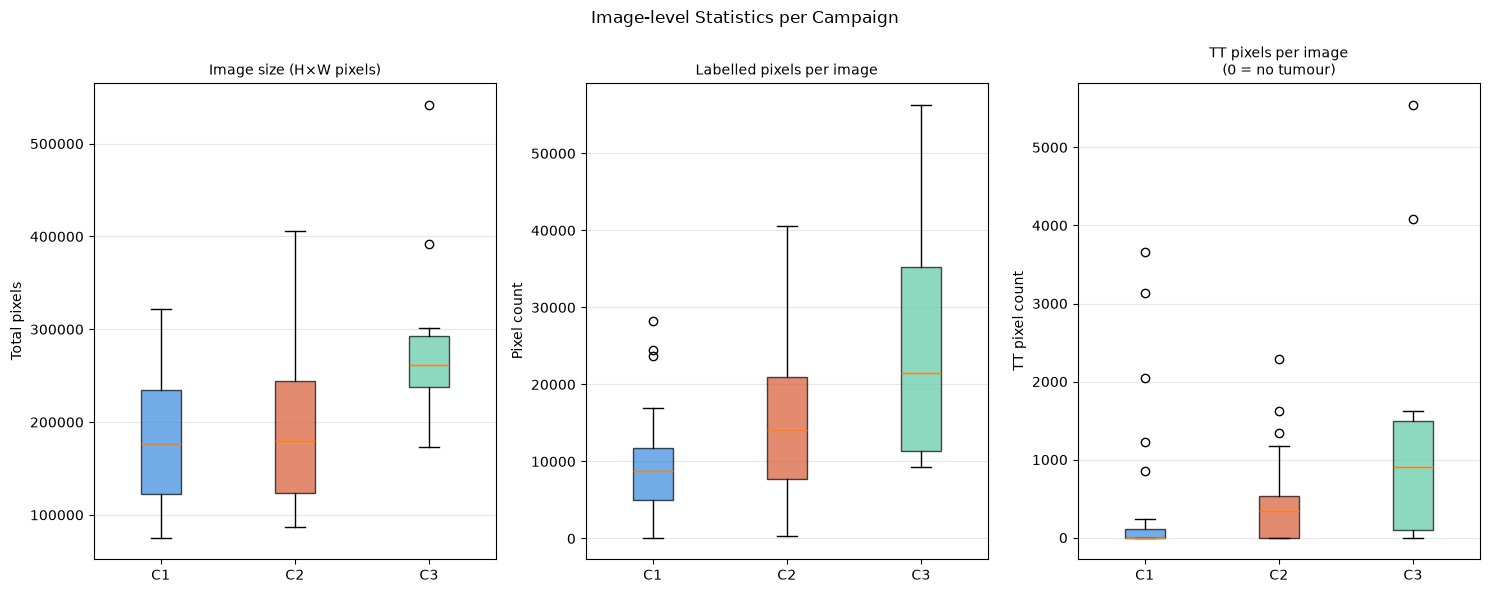

Saved → ../results/campaign_image_stats.png

════════════════════════════════════════════════════════════
  IMAGE-LEVEL STATISTICS PER CAMPAIGN
════════════════════════════════════════════════════════════
+------------+--------+--------------------+--------------+--------------+-----------+
|  Campaign  | Images | Median labelled px | Median TT px | Images w/ TT | Max TT px |
+------------+--------+--------------------+--------------+--------------+-----------+
| Campaign 1 |   27   |       8,803        |      0       |   9 (33%)    |   3,655   |
| Campaign 2 |   24   |       14,100       |     345      |   17 (71%)   |   2,295   |
| Campaign 3 |   10   |       21,480       |     908      |   7 (70%)    |   5,549   |
+------------+--------+--------------------+--------------+--------------+-----------+


In [10]:
# ── Image-level statistics per campaign ──────────────────────────────
def plot_image_level_stats(campaigns: dict):
    """
    Box plots of image-level statistics per campaign:
      - Total labelled pixels per image
      - TT pixel count per image
      - Image dimensions (H × W)
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle("Image-level Statistics per Campaign", fontsize=12)

    labelled_px = {c: [] for c in [1, 2, 3]}
    tt_px       = {c: [] for c in [1, 2, 3]}
    image_sizes = {c: [] for c in [1, 2, 3]}

    for c_id, patients in campaigns.items():
        for p in patients:
            label_map = p['labels']
            labelled_px[c_id].append((label_map > 0).sum())
            tt_px[c_id].append((label_map == 2).sum())
            H, W = label_map.shape
            image_sizes[c_id].append(H * W)

    def _box(ax, data_dict, title, ylabel, log=False):
        data   = [data_dict[c] for c in [1, 2, 3]]
        colors = [CAMPAIGN_COLORS[c] for c in [1, 2, 3]]
        bp     = ax.boxplot(data, patch_artist=True, notch=False)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticklabels([f"C{c}" for c in [1, 2, 3]])
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3, axis='y')
        if log:
            ax.set_yscale('log')

    _box(axes[0], image_sizes,   "Image size (H×W pixels)",
         "Total pixels", log=False)
    _box(axes[1], labelled_px,   "Labelled pixels per image",
         "Pixel count")
    _box(axes[2], tt_px,         "TT pixels per image\n(0 = no tumour)",
         "TT pixel count")

    plt.tight_layout()
    out = RESULTS_DIR / "campaign_image_stats.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")

    # Print summary stats
    print(f"\n{'═'*60}")
    print("  IMAGE-LEVEL STATISTICS PER CAMPAIGN")
    print(f"{'═'*60}")
    stat_table = PrettyTable()
    stat_table.field_names = [
        "Campaign", "Images", "Median labelled px",
        "Median TT px", "Images w/ TT", "Max TT px"
    ]
    for c_id in [1, 2, 3]:
        tt   = tt_px[c_id]
        lab  = labelled_px[c_id]
        stat_table.add_row([
            f"Campaign {c_id}",
            len(tt),
            f"{int(np.median(lab)):,}",
            f"{int(np.median(tt)):,}",
            f"{sum(1 for t in tt if t > 0)} ({sum(1 for t in tt if t > 0)/len(tt)*100:.0f}%)",
            f"{max(tt):,}",
        ])
    print(stat_table)


plot_image_level_stats(campaigns)

In [11]:
# ── Summary — campaign comparison ────────────────────────────────────
def print_campaign_summary(campaign_stats: dict,
                            campaign_spectra: dict):
    """Print a unified summary of all campaign characteristics."""
    print(f"\n{'═'*70}")
    print("  CAMPAIGN EDA SUMMARY")
    print(f"{'═'*70}")

    for c_id in [1, 2, 3]:
        s      = campaign_stats[c_id]
        nt_px  = campaign_spectra[c_id][0]
        tt_px  = campaign_spectra[c_id][1]

        sam_deg = float('nan')
        if len(nt_px) > 0 and len(tt_px) > 0:
            nt_m    = nt_px.mean(axis=0)
            tt_m    = tt_px.mean(axis=0)
            sam_deg = float(np.degrees(np.arccos(np.clip(
                np.dot(nt_m, tt_m) /
                (np.linalg.norm(nt_m) * np.linalg.norm(tt_m) + 1e-8),
                -1, 1
            ))))

        print(f"\n  Campaign {c_id}")
        print(f"  {'─'*40}")
        print(f"  Images          : {s['n_images']}")
        print(f"  Patients        : {s['n_patients']}")
        print(f"  Images with TT  : {s['n_images_with_tt']} "
              f"({s['tt_pct_images']:.0f}%)")
        print(f"  TT pixel %      : {s['pcts'][1]:.2f}%")
        print(f"  NT:TT ratio     : {s['nt_tt_ratio']:.1f}")
        print(f"  NT vs TT SAM°   : {sam_deg:.2f}°")
        if len(tt_px) > 0:
            print(f"  TT intra-var    : {tt_px.std(axis=0).mean():.4f}")


print_campaign_summary(campaign_stats, campaign_spectra)


══════════════════════════════════════════════════════════════════════
  CAMPAIGN EDA SUMMARY
══════════════════════════════════════════════════════════════════════

  Campaign 1
  ────────────────────────────────────────
  Images          : 27
  Patients        : 16
  Images with TT  : 9 (33%)
  TT pixel %      : 4.22%
  NT:TT ratio     : 8.9
  NT vs TT SAM°   : 2.00°
  TT intra-var    : 0.1040

  Campaign 2
  ────────────────────────────────────────
  Images          : 24
  Patients        : 10
  Images with TT  : 17 (71%)
  TT pixel %      : 2.99%
  NT:TT ratio     : 16.3
  NT vs TT SAM°   : 3.47°
  TT intra-var    : 0.0958

  Campaign 3
  ────────────────────────────────────────
  Images          : 10
  Patients        : 8
  Images with TT  : 7 (70%)
  TT pixel %      : 5.80%
  NT:TT ratio     : 1.4
  NT vs TT SAM°   : 4.06°
  TT intra-var    : 0.0711
